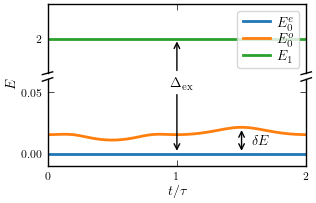

In [1]:
import matplotlib.pyplot as plt  # plotting library
import numpy as np  # general math functions 

plt.style.use('aps.mplstyle')

T = 300    # period
# load data
E_t = np.load('data/fig4b_adaptive_energy_levels.npz')['E_t']
times = np.load('data/fig4b_adaptive_energy_levels.npz')['times']

# plot the energy spectrum
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True,
    gridspec_kw={'height_ratios': [1, 1.25], 'hspace': 0.08}
)

for axis in (ax_top, ax_bottom):
    axis.plot(times/T, E_t[:, 0] - E_t[:, 0], linewidth=2, label=r'$E^e_0$')
    axis.plot(times/T, E_t[:, 2] - E_t[:, 0], linewidth=2, label=r'$E^o_0$')
    axis.plot(times/T, E_t[:, 4] - E_t[:, 0], linewidth=2, label=r'$E_1$')

ax_bottom.set_ylim(-0.01, 0.06)
ax_top.set_ylim(1.95, 2.05)

ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(bottom=False, labelbottom=False)

# Hide the spines between the two subplots.
ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(axis='x', bottom=False, labelbottom=False)
ax_bottom.tick_params(axis='x', top=False, labeltop=False)

# Add diagonal lines to indicate the break in the y-axis.
d = 0.02
kwargs = dict(color='k', clip_on=False, linewidth=1)

ax_top.plot((-d, d), (-d, d),
            transform=ax_top.transAxes, **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, d),
            transform=ax_top.transAxes, **kwargs)

ax_bottom.plot((-d, d), (1 - d, 1 + d),
               transform=ax_bottom.transAxes, **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d),
               transform=ax_bottom.transAxes, **kwargs)

fig.text(0.015, 0.5, r'$E$', rotation='vertical', va='center')
ax_bottom.set_xlabel(r'$t/\tau$')
ax_top.legend(frameon=True)
fig.subplots_adjust(left=0.14)

ax_top.set_ylim(1.95, 2.05)
ax_top.set_yticks([2.0])
ax_bottom.set_ylim(-0.01, 0.06)
ax_bottom.set_yticks([0.0, 0.05])
ax_bottom.set_xlim(0, 2)
ax_bottom.set_xticks(np.arange(0, 2.1, 1.0))

# delta E
x_gap = 1.5
i_gap = np.argmin(np.abs(times / T - x_gap))

y0 = E_t[i_gap, 0] - E_t[i_gap, 0]
y2 = E_t[i_gap, 2] - E_t[i_gap, 0]

ax_bottom.annotate(
    '',
    xy=(x_gap, y2),
    xytext=(x_gap, y0),
    arrowprops=dict(
        arrowstyle='<->',
        color='black',
        linewidth=1.0
    )
)

ax_bottom.text(
    x_gap + 0.08,
    (y0 + y2) / 2,
    r'$\delta E$',
    color='black',
    va='center'
)

# Delta_bulk
x_bulk = 1.0

ax_top.annotate(
    '',
    xy=(x_bulk, 2.00),
    xytext=(x_bulk, 1.95),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        linewidth=1.0
    )
)

ax_bottom.annotate(
    '',
    xy=(x_bulk, 0.00),
    xytext=(x_bulk, 0.05),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        linewidth=1.0
    )
)

fig.text(
    0.50, 0.50,
    r'$\Delta_{\mathrm{ex}}$',
    color='black',
    va='center',
    ha='left'
)

plt.savefig('figures/adaptive_ spatial_shift.pdf', dpi=300, bbox_inches='tight')
plt.show()